In [1]:
# Check if GPU is available and set random seeds for reproducibility
import torch
import numpy as np
import random
import os

# Set seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Check GPU
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()



CUDA Available: True
GPU Name: Tesla T4
GPU Memory: 15.64 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/dataset.zip /content/
!unzip -q /content/dataset.zip -d /content/SignDETR-VSL

In [4]:
import os

ROOT = "/content/SignDETR-VSL"
splits = ["train", "valid", "test"]

def count_files(path, exts):
    return len([f for f in os.listdir(path) if f.lower().endswith(exts)])

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    n_imgs = count_files(img_dir, (".jpg", ".png", ".jpeg"))
    n_lbls = count_files(lbl_dir, (".txt",))

    print(f"{split.upper():5} | images: {n_imgs:5} | labels: {n_lbls:5}")


TRAIN | images:  2691 | labels:  2691
VALID | images:   288 | labels:   288
TEST  | images:   123 | labels:   123


In [5]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [6]:
!find /content/SignDETR-VSL -maxdepth 2 -type d


/content/SignDETR-VSL
/content/SignDETR-VSL/train
/content/SignDETR-VSL/train/labels
/content/SignDETR-VSL/train/images
/content/SignDETR-VSL/valid
/content/SignDETR-VSL/valid/labels
/content/SignDETR-VSL/valid/images
/content/SignDETR-VSL/test
/content/SignDETR-VSL/test/labels
/content/SignDETR-VSL/test/images


In [7]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [8]:
import os
import cv2
import matplotlib.pyplot as plt

LABEL_ID = 5  # đổi nhãn bạn muốn xem

IMG_DIR = "/content/SignDETR-VSL/train/images"
LBL_DIR = "/content/SignDETR-VSL/train/labels"

images_with_label = []

for lbl_file in os.listdir(LBL_DIR):
    lbl_path = os.path.join(LBL_DIR, lbl_file)
    with open(lbl_path, "r") as f:
        for line in f:
            if int(line.split()[0]) == LABEL_ID:
                img_name = lbl_file.replace(".txt", ".jpg")  # hoặc .png
                images_with_label.append(img_name)
                break

print(f"Tìm thấy {len(images_with_label)} ảnh có nhãn {LABEL_ID}")

Tìm thấy 141 ảnh có nhãn 5


In [9]:
# for img_name in images_with_label:
#     img_path = os.path.join(IMG_DIR, img_name)
#     img = cv2.imread(img_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     plt.figure(figsize=(4,4))
#     plt.imshow(img)
#     plt.axis("off")
#     plt.title(img_name)
#     plt.show()

In [10]:
def draw_yolo_bbox(img, label_path):
    h, w, _ = img.shape
    with open(label_path, "r") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    return img

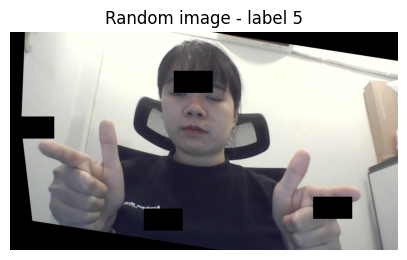

In [11]:
import random

random_img = random.choice(images_with_label)

img_path = os.path.join(IMG_DIR, random_img)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Random image - label {LABEL_ID}")
plt.show()

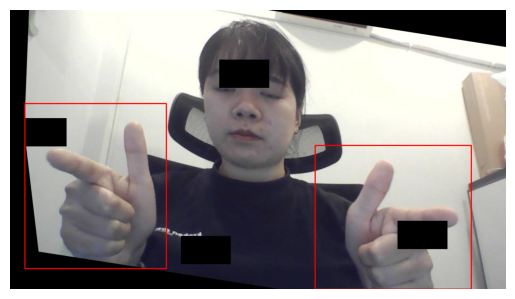

In [12]:
lbl_path = os.path.join(LBL_DIR, random_img.replace(".jpg", ".txt"))
img_box = draw_yolo_bbox(img.copy(), lbl_path)

plt.imshow(img_box)
plt.axis("off")
plt.show()

In [13]:
names = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L',
         'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']

id2name = {i: name for i, name in enumerate(names)}
name2id = {name: i for i, name in enumerate(names)}

print(id2name)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'G', 6: 'H', 7: 'I', 8: 'K', 9: 'L', 10: 'M', 11: 'N', 12: 'O', 13: 'P', 14: 'Q', 15: 'R', 16: 'S', 17: 'T', 18: 'U', 19: 'V', 20: 'X', 21: 'Y'}


In [14]:
import subprocess
import sys

packages = [
    'albumentations',
    'colorama',
    'rich',
    'torchinfo',
    'scipy'
]

print("Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("All packages installed successfully!")

# Verify PyTorch installation
print(f"\nPyTorch version: {torch.__version__}")
print(f"TorchVision version: {__import__('torchvision').__version__}")

Installing required packages...
All packages installed successfully!

PyTorch version: 2.10.0+cu128
TorchVision version: 0.25.0+cu128


## mô hình DETR

In [15]:
import torch
from torch import nn
from torchvision.models import swin_t, Swin_T_Weights
import math

def _get_1d_sincos_pos_embed(length: int, dim: int, temperature: float = 10000.0, device=None):
    assert dim % 2 == 0
    position = torch.arange(length, device=device, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, device=device, dtype=torch.float32) * (-math.log(temperature) / dim)
    )
    pe = torch.zeros(length, dim, device=device, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

def build_2d_sincos_position_embedding(height: int, width: int, dim: int, device=None):
    assert dim % 2 == 0, "positional dim must be even"
    dim_half = dim // 2
    pe_y = _get_1d_sincos_pos_embed(height, dim_half, device=device)
    pe_x = _get_1d_sincos_pos_embed(width, dim_half, device=device)
    pos = torch.zeros(height, width, dim, device=device, dtype=torch.float32)
    pos[:, :, :dim_half] = pe_y[:, None, :].expand(-1, width, -1)
    pos[:, :, dim_half:] = pe_x[None, :, :].expand(height, -1, -1)
    pos = pos.view(1, height * width, dim)
    return pos

class DETR(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, nheads=8,
                 num_encoder_layers=1, num_decoder_layers=1, num_queries=25):
        super().__init__()

        #  Swin-T backbone
        self.backbone = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)
        # Bỏ đi lớp classification head của Swin-T
        self.backbone.head = nn.Identity()

        # 2. Lớp chuyển đổi chiều (Swin-T xuất ra 768 channels thay vì 2048 như ResNet50)
        self.conv = nn.Conv2d(768, hidden_dim, 1)

        # Transformer
        self.transformer = nn.Transformer(
            hidden_dim, nheads, num_encoder_layers, num_decoder_layers,
            batch_first=True, dropout=0.1)

        # Prediction heads
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)
        self.linear_bbox = nn.Linear(hidden_dim, 4)

        # Query embeddings
        self.num_queries = num_queries
        self.query_pos = nn.Parameter(torch.randn(self.num_queries, hidden_dim))

        # Normalizations
        self.norm_src = nn.LayerNorm(hidden_dim)
        self.norm_tgt = nn.LayerNorm(hidden_dim)

    def forward(self, inputs):
        # 3. Trích xuất feature ngắn gọn thông qua module `features`
        x = self.backbone.features(inputs)
        # Swin-T xuất ra [B, H, W, C], cần chuyển sang [B, C, H, W] cho Conv2d
        x = x.permute(0, 3, 1, 2)

        feat = self.conv(x)
        bsz, d_model, Hf, Wf = feat.shape
        src = feat.flatten(2).permute(0, 2, 1)

        pos = build_2d_sincos_position_embedding(Hf, Wf, d_model, device=feat.device)
        src = self.norm_src(src + pos)

        tgt = torch.zeros(bsz, self.num_queries, d_model, device=feat.device)
        query_pos = self.query_pos.unsqueeze(0).expand(bsz, -1, -1)
        tgt = self.norm_tgt(tgt + query_pos)

        hs = self.transformer(src=src, tgt=tgt)

        return {
            'pred_logits': self.linear_class(hs),
            'pred_boxes': self.linear_bbox(hs).sigmoid()
        }

print("DETR model with Swin-T backbone defined")

DETR model with Swin-T backbone defined


In [16]:
CLASSES = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']

In [17]:
# Define utility functions for boxes and data
from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

def box_cxcywh_to_xyxy(x):
    """Convert boxes from (cx, cy, w, h) to (x1, y1, x2, y2)"""
    x0, y0, w, h = x.unbind(-1)
    b = [(x0 - 0.5 * w), (y0 - 0.5 * h), (x0 + 0.5 * w), (y0 + 0.5 * h)]
    return torch.stack(b, dim=-1)

def generalized_box_iou(boxes1, boxes2):
    """Compute the IoU between boxes"""
    assert (boxes1[:, 2:] >= boxes1[:, :2]).all()
    assert (boxes2[:, 2:] >= boxes2[:, :2]).all()

    iou, union = box_iou(boxes1, boxes2)

    lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    enc_area = wh[:, :, 0] * wh[:, :, 1]

    return iou - (enc_area - union) / enc_area

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    iou = inter / union
    return iou, union

def rescale_bboxes(out_bbox, size):
    """Rescale bounding boxes from normalized coordinates"""
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=b.dtype, device=b.device)
    return b

def stacker(batch):
    """Stack batch items"""
    images, targets = [], []
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    return torch.stack(images), targets

def get_classes():
    return CLASSES

def get_colors():
    return [(0, 255, 0), (255, 0, 0), (0, 0, 255)]

print("Utility functions defined")

Utility functions defined


In [18]:
# Define Loss Functions
class HungarianMatcher(nn.Module):
    """Hungarian matching for DETR"""
    def __init__(self, weight_dict: dict):
        super().__init__()
        self.class_weighting = weight_dict.get('class_weighting')
        self.bbox_weighting = weight_dict.get('bbox_weighting')
        self.giou_weighting = weight_dict.get('giou_weighting')

    @torch.no_grad()
    def forward(self, yhat, y):
        indices = []
        for batch_idx, target in enumerate(y):
            batch_logits = yhat["pred_logits"][batch_idx]
            batch_boxes = yhat["pred_boxes"][batch_idx]
            batch_prob = batch_logits.softmax(-1)

            tgt_labels = target["labels"].to(torch.long)
            tgt_boxes = target["boxes"].to(batch_boxes.dtype)

            cost_class = -batch_prob[:, tgt_labels]
            cost_bbox = torch.cdist(batch_boxes, tgt_boxes, p=1)
            cost_giou = -generalized_box_iou(
                box_cxcywh_to_xyxy(batch_boxes),
                box_cxcywh_to_xyxy(tgt_boxes)
            )

            C_batch = (self.bbox_weighting * cost_bbox +
                      self.class_weighting * cost_class +
                      self.giou_weighting * cost_giou).cpu()

            ii, jj = linear_sum_assignment(C_batch)
            indices.append(
                (torch.as_tensor(ii, dtype=torch.int64), torch.as_tensor(jj, dtype=torch.int64))
            )
        return indices

class DETRLoss(nn.Module):
    """DETR Loss computation"""
    def __init__(self, num_classes, matcher, weight_dict, eos_coef):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.weight_dict = weight_dict
        self.eos_coef = eos_coef
        empty_weight = torch.ones(self.num_classes + 1)
        empty_weight[-1] = self.eos_coef
        self.register_buffer('empty_weight', empty_weight)

    def classification_loss(self, yhat, y, indices):
        src_logits = yhat['pred_logits']
        idx = self.get_matched_query_indices(indices)
        target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(y, indices)])
        target_classes = torch.full(src_logits.shape[:2], self.num_classes,
                                  dtype=torch.int64, device=src_logits.device)
        target_classes[idx] = target_classes_o
        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, self.empty_weight)
        return {'loss_ce': loss_ce}

    def box_loss(self, yhat, y, indices, num_boxes):
        idx = self.get_matched_query_indices(indices)
        src_boxes = yhat['pred_boxes'][idx]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(y, indices)], dim=0)

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='none')
        loss_bbox_sum = loss_bbox.sum() / num_boxes

        loss_giou = 1 - torch.diag(generalized_box_iou(
            box_cxcywh_to_xyxy(src_boxes),
            box_cxcywh_to_xyxy(target_boxes)))
        loss_giou_sum = loss_giou.sum() / num_boxes

        return {'loss_bbox': loss_bbox_sum, 'loss_giou': loss_giou_sum}

    def get_matched_query_indices(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def forward(self, yhat, y):
        indices = self.matcher(yhat, y)
        device = next(iter(yhat.values())).device
        y = [{'labels': t['labels'].to(torch.long), 'boxes': t['boxes'].to(torch.float32)} for t in y]

        num_boxes = sum(len(t["labels"]) for t in y)
        num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=device).clamp(min=1)

        return {
            'labels': self.classification_loss(yhat, y, indices),
            'boxes': self.box_loss(yhat, y, indices, num_boxes)
        }

print("Loss functions defined")

Loss functions defined


In [19]:
import os
import glob
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class DETRData(Dataset):
    def __init__(self, path, train=True):
        super().__init__()
        self.path = path
        self.labels_path = os.path.join(self.path, 'labels')
        self.images_path = os.path.join(self.path, 'images')

        if os.path.exists(self.labels_path):
            self.label_files = os.listdir(self.labels_path)
            self.labels = list(filter(lambda x: x.endswith('.txt'), self.label_files))
        else:
            self.labels = []
            print(f"Cảnh báo: Không tìm thấy thư mục labels tại {self.labels_path}")

        self.train = train

    def safe_transform(self, image, bboxes, labels, max_attempts=50):

        self.transform = A.Compose(
            [

                A.LongestMaxSize(max_size=600) if self.train else A.NoOp(),
                A.PadIfNeeded(min_height=512, min_width=512, border_mode=0) if self.train else A.NoOp(),

                # Random crop (chỉ khi train)
                *([A.RandomCrop(width=512, height=512, p=0.5)] if self.train else []),

                # Resize về kích thước cuối cùng
                A.Resize(384, 384),


                *([A.HorizontalFlip(p=0.5)] if self.train else []),
                *([A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2, p=0.4)] if self.train else []),

                # Normalize theo ImageNet (Swin-T pretrained)
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ],
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.1)
        )

        for attempt in range(max_attempts):
            try:
                transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
                if len(transformed['bboxes']) > 0:
                    return transformed
            except Exception as e:
                continue

        # Fallback: Chỉ resize và normalize
        fallback = A.Compose([
            A.Resize(384, 384),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

        return fallback(image=image, bboxes=bboxes, class_labels=labels)


    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_filename = self.labels[idx]
        label_path = os.path.join(self.labels_path, label_filename)

        # Tìm ảnh (xử lý lỗi tên file Roboflow)
        image_name_base = os.path.splitext(label_filename)[0]
        search_pattern = os.path.join(self.images_path, image_name_base + "*")
        found_images = glob.glob(search_pattern)

        if len(found_images) == 0:
            return self.__getitem__((idx + 1) % len(self))

        image_path = found_images[0]

        try:
            img = Image.open(image_path).convert('RGB')
            w_img, h_img = img.size # Kích thước ảnh gốc

            with open(label_path, 'r') as f:
                annotations = f.readlines()

            class_labels = []
            bounding_boxes = []

            for annotation in annotations:
                parts = annotation.strip().split()
                if len(parts) < 5: continue

                cls_id = int(parts[0])
                coords = [float(x) for x in parts[1:]]

                # ---  POLYGON -> BBOX ---
                if len(coords) > 4:

                    xs = coords[0::2]
                    ys = coords[1::2]

                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)

                    w = x_max - x_min
                    h = y_max - y_min
                    x_c = x_min + w / 2
                    y_c = y_min + h / 2
                else:

                    x_c, y_c, w, h = coords


                x_min = np.clip(x_c - w/2, 0.0, 1.0)
                y_min = np.clip(y_c - h/2, 0.0, 1.0)
                x_max = np.clip(x_c + w/2, 0.0, 1.0)
                y_max = np.clip(y_c + h/2, 0.0, 1.0)


                w = x_max - x_min
                h = y_max - y_min
                x_c = x_min + w/2
                y_c = y_min + h/2


                if w > 0.001 and h > 0.001:
                    class_labels.append(cls_id)
                    bounding_boxes.append([x_c, y_c, w, h])

            if len(class_labels) == 0:
                return self.__getitem__((idx + 1) % len(self))

            class_labels = np.array(class_labels)
            bounding_boxes = np.array(bounding_boxes)

            # Augmentation
            augmented = self.safe_transform(image=np.array(img), bboxes=bounding_boxes, labels=class_labels)

            augmented_img_tensor = augmented['image']
            augmented_bounding_boxes = np.array(augmented['bboxes'])
            augmented_classes = augmented['class_labels']

            if len(augmented_bounding_boxes) == 0:
                 return self.__getitem__((idx + 1) % len(self))

            labels = torch.tensor(augmented_classes, dtype=torch.long)
            boxes = torch.tensor(augmented_bounding_boxes, dtype=torch.float32)

            return augmented_img_tensor, {'labels': labels, 'boxes': boxes}

        except Exception as e:
            print(f"Bỏ qua file lỗi {label_filename}: {str(e)}")
            return self.__getitem__((idx + 1) % len(self))

## load dataset

In [20]:
DATA_DIR = "/content/SignDETR-VSL/"


In [21]:
# Initialize training components
from torch import optim
from torch.utils.data import DataLoader
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training configuration
num_classes = 22
batch_size = 4
learning_rate = 1e-5
num_epochs = 100


# Create datasets and dataloaders
print("Loading datasets...")
train_dataset = DETRData(os.path.join(DATA_DIR, 'train'), train=True)
valid_dataset = DETRData(os.path.join(DATA_DIR, 'valid'), train=False)
test_dataset = DETRData(os.path.join(DATA_DIR, 'test'), train=False)

# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)
# valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)
# Dành cho tập train
train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=stacker
)

# Dành cho tập validation
valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=stacker
)


test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Valid samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Using device: cuda
Loading datasets...
Train samples: 2691
Valid samples: 288
Test samples: 123


In [22]:
# Initialize model, optimizer, loss, and scheduler
print("Initializing model and training components...")

# Create model
model = DETR(num_classes=num_classes, hidden_dim=256, nheads=8,
             num_encoder_layers=1, num_decoder_layers=1, num_queries=25)


model = model.to(device)
print(f"Model moved to {device}")

# Loss weights
weights = {
    'class_weighting': 1.0,
    'bbox_weighting': 5.0,
    'giou_weighting': 2.0
}

# Create matcher and loss function
matcher = HungarianMatcher(weights)
criterion = DETRLoss(num_classes=num_classes, matcher=matcher,
                     weight_dict=weights, eos_coef=0.1)
criterion = criterion.to(device)
# Optimizer and scheduler
param_dicts = [
    {
        "params": [p for n, p in model.named_parameters()
                   if "backbone" not in n and p.requires_grad],
        "lr": 1e-4
    },
    {
        "params": [p for n, p in model.named_parameters()
                   if "backbone" in n and p.requires_grad],
        "lr": 1e-5
    },
]

optimizer = torch.optim.AdamW(
    param_dicts,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[60, 80],
    gamma=0.1
)

print("Model initialized successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Initializing model and training components...
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:02<00:00, 51.9MB/s]


Model moved to cuda
Model initialized successfully!
Total parameters: 30,625,429
Trainable parameters: 30,625,429


##Training

In [23]:
output_dir = '/content/drive/MyDrive/NCKH_SignDETR_VSL/swin_t_v2/output'
log_dir = '/content/drive/MyDrive/NCKH_SignDETR_VSL/swin_t_v2/logs'



In [24]:
import time
import copy
from tqdm import tqdm
import shutil
# Lưu backup sau mỗi epoch

def train_one_epoch(model, dataloader, criterion, optimizer, device, weights):
    model.train()
    total_loss_epoch = 0.0
    loss_ce_epoch = 0.0
    loss_bbox_epoch = 0.0
    loss_giou_epoch = 0.0

    # Dùng tqdm để tạo thanh tiến trình
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, targets in pbar:
        # Chuyển dữ liệu lên GPU/CPU
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        outputs = model(images)
        loss_dict = criterion(outputs, targets)

        # Lấy từng thành phần loss
        loss_ce = loss_dict['labels']['loss_ce']
        loss_bbox = loss_dict['boxes']['loss_bbox']
        loss_giou = loss_dict['boxes']['loss_giou']

        loss = (weights['class_weighting'] * loss_ce +
                weights['bbox_weighting'] * loss_bbox +
                weights['giou_weighting'] * loss_giou)

        # Backward pass và tối ưu hóa
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping: Giúp DETR hội tụ ổn định hơn
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        # Cộng dồn loss để tính trung bình
        total_loss_epoch += loss.item()
        loss_ce_epoch += loss_ce.item()
        loss_bbox_epoch += loss_bbox.item()
        loss_giou_epoch += loss_giou.item()

        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    n = len(dataloader)
    return {
        'total_loss': total_loss_epoch / n,
        'loss_ce': loss_ce_epoch / n,
        'loss_bbox': loss_bbox_epoch / n,
        'loss_giou': loss_giou_epoch / n
    }

@torch.no_grad()
def evaluate(model, dataloader, criterion, device, weights):
    model.eval()
    total_loss_epoch = 0.0
    loss_ce_epoch = 0.0
    loss_bbox_epoch = 0.0
    loss_giou_epoch = 0.0

    pbar = tqdm(dataloader, desc="Evaluating", leave=False)
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)
        loss_dict = criterion(outputs, targets)

        loss_ce = loss_dict['labels']['loss_ce']
        loss_bbox = loss_dict['boxes']['loss_bbox']
        loss_giou = loss_dict['boxes']['loss_giou']

        loss = (weights['class_weighting'] * loss_ce +
                weights['bbox_weighting'] * loss_bbox +
                weights['giou_weighting'] * loss_giou)

        total_loss_epoch += loss.item()
        loss_ce_epoch += loss_ce.item()
        loss_bbox_epoch += loss_bbox.item()
        loss_giou_epoch += loss_giou.item()

    n = len(dataloader)
    return {
        'total_loss': total_loss_epoch / n,
        'loss_ce': loss_ce_epoch / n,
        'loss_bbox': loss_bbox_epoch / n,
        'loss_giou': loss_giou_epoch / n
    }

In [25]:
import os
import time
import json
import torch

drive_dir = '/content/drive/MyDrive/NCKH_SignDETR_VSL/swin_t_v2/output/'
os.makedirs(drive_dir, exist_ok=True)

# Khai báo các file cần lưu
best_model_path = os.path.join(drive_dir, 'best_signdetr_model.pth')
history_path = os.path.join(drive_dir, 'training_history.json')
log_path = os.path.join(drive_dir, 'training_log.txt')

# Cài đặt tần suất lưu thêm epoch (Ví dụ: 5 epoch lưu 1 lần)
save_freq = 5

# 2. Cấu trúc lưu lịch sử training
history = {
    'train_loss': [], 'val_loss': [],
    'train_ce': [], 'val_ce': [],
    'train_bbox': [], 'val_bbox': [],
    'train_giou': [], 'val_giou': [],
    'lr': []
}

best_val_loss = float('inf')

def log_and_print(text, log_file):
    print(text)
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(text + '\n')

log_and_print(f"Bắt đầu training {num_epochs} epochs...", log_path)

for epoch in range(num_epochs):
    start_time = time.time()

    # Train 1 epoch
    train_metrics = train_one_epoch(model, train_dataloader, criterion, optimizer, device, weights)

    # Evaluate trên tập validation
    val_metrics = evaluate(model, valid_dataloader, criterion, device, weights)

    # Cập nhật learning rate scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Ghi nhận lịch sử
    history['train_loss'].append(train_metrics['total_loss'])
    history['val_loss'].append(val_metrics['total_loss'])
    history['train_ce'].append(train_metrics['loss_ce'])
    history['val_ce'].append(val_metrics['loss_ce'])
    history['train_bbox'].append(train_metrics['loss_bbox'])
    history['val_bbox'].append(val_metrics['loss_bbox'])
    history['train_giou'].append(train_metrics['loss_giou'])
    history['val_giou'].append(val_metrics['loss_giou'])
    history['lr'].append(current_lr)

    # LƯU HISTORY THÀNH FILE JSON
    with open(history_path, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=4)

    saved_msg = ""

    # LƯU MODEL TỐT NHẤT (BEST MODEL)
    if val_metrics['total_loss'] < best_val_loss:
        best_val_loss = val_metrics['total_loss']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_val_loss,
        }, best_model_path)
        saved_msg += " [Best Model]"

    # LƯU THÊM CÁC EPOCH ĐỊNH KỲ HOẶC EPOCH CUỐI CÙNG (CHECKPOINT)
    if (epoch + 1) % save_freq == 0 or (epoch + 1) == num_epochs:
        checkpoint_path = os.path.join(drive_dir, f'checkpoint_epoch_{epoch+1:03d}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_metrics['total_loss'],
        }, checkpoint_path)
        saved_msg += f" [Saved Checkpoint Ep {epoch+1}]"

    epoch_time = time.time() - start_time

    # GHI LOG CHO EPOCH HIỆN TẠI
    log_str1 = f"Epoch {epoch+1:03d}/{num_epochs} | Thời gian: {epoch_time:.0f}s | LR: {current_lr:.2e}"
    log_str2 = f"  Train Loss: {train_metrics['total_loss']:.4f} (CE:{train_metrics['loss_ce']:.4f}, BBox:{train_metrics['loss_bbox']:.4f}, GIoU:{train_metrics['loss_giou']:.4f})"
    log_str3 = f"  Val Loss:   {val_metrics['total_loss']:.4f} (CE:{val_metrics['loss_ce']:.4f}, BBox:{val_metrics['loss_bbox']:.4f}, GIoU:{val_metrics['loss_giou']:.4f}){saved_msg}\n"

    log_and_print(log_str1, log_path)
    log_and_print(log_str2, log_path)
    log_and_print(log_str3, log_path)

log_and_print("Training hoàn tất!", log_path)

Bắt đầu training 100 epochs...


Epoch 001/100 | Thời gian: 155s | LR: 1.00e-04
  Train Loss: 3.6234 (CE:1.9185, BBox:0.1665, GIoU:0.4361)
  Val Loss:   4.0444 (CE:1.9243, BBox:0.2405, GIoU:0.4588) [Best Model]



Epoch 002/100 | Thời gian: 148s | LR: 1.00e-04
  Train Loss: 3.0926 (CE:1.8029, BBox:0.1214, GIoU:0.3413)
  Val Loss:   3.8859 (CE:1.6610, BBox:0.2557, GIoU:0.4733) [Best Model]



Epoch 003/100 | Thời gian: 148s | LR: 1.00e-04
  Train Loss: 2.6512 (CE:1.3958, BBox:0.1174, GIoU:0.3343)
  Val Loss:   3.6496 (CE:1.2961, BBox:0.2702, GIoU:0.5011) [Best Model]



Epoch 004/100 | Thời gian: 149s | LR: 1.00e-04
  Train Loss: 2.3175 (CE:1.1300, BBox:0.1107, GIoU:0.3170)
  Val Loss:   3.2215 (CE:1.1186, BBox:0.2397, GIoU:0.4521) [Best Model]



...

Epoch 096/100 | Thời gian: 144s | LR: 1.00e-06
  Train Loss: 0.4135 (CE:0.0127, BBox:0.0367, GIoU:0.1088)
  Val Loss:   1.9290 (CE:0.1144, BBox:0.2070, GIoU:0.3898)



Epoch 097/100 | Thời gian: 142s | LR: 1.00e-06
  Train Loss: 0.4098 (CE:0.0123, BBox:0.0365, GIoU:0.1076)
  Val Loss:   1.9334 (CE:0.1142, BBox:0.2077, GIoU:0.3905)



Epoch 098/100 | Thời gian: 143s | LR: 1.00e-06
  Train Loss: 0.4093 (CE:0.0138, BBox:0.0362, GIoU:0.1073)
  Val Loss:   1.9350 (CE:0.1136, BBox:0.2078, GIoU:0.3912)



Epoch 099/100 | Thời gian: 143s | LR: 1.00e-06
  Train Loss: 0.4084 (CE:0.0118, BBox:0.0363, GIoU:0.1074)
  Val Loss:   1.9428 (CE:0.1158, BBox:0.2086, GIoU:0.3921)



Epoch 100/100 | Thời gian: 144s | LR: 1.00e-06
  Train Loss: 0.4113 (CE:0.0125, BBox:0.0366, GIoU:0.1079)
  Val Loss:   1.9324 (CE:0.1149, BBox:0.2076, GIoU:0.3898) [Saved Checkpoint Ep 100]

Training hoàn tất!


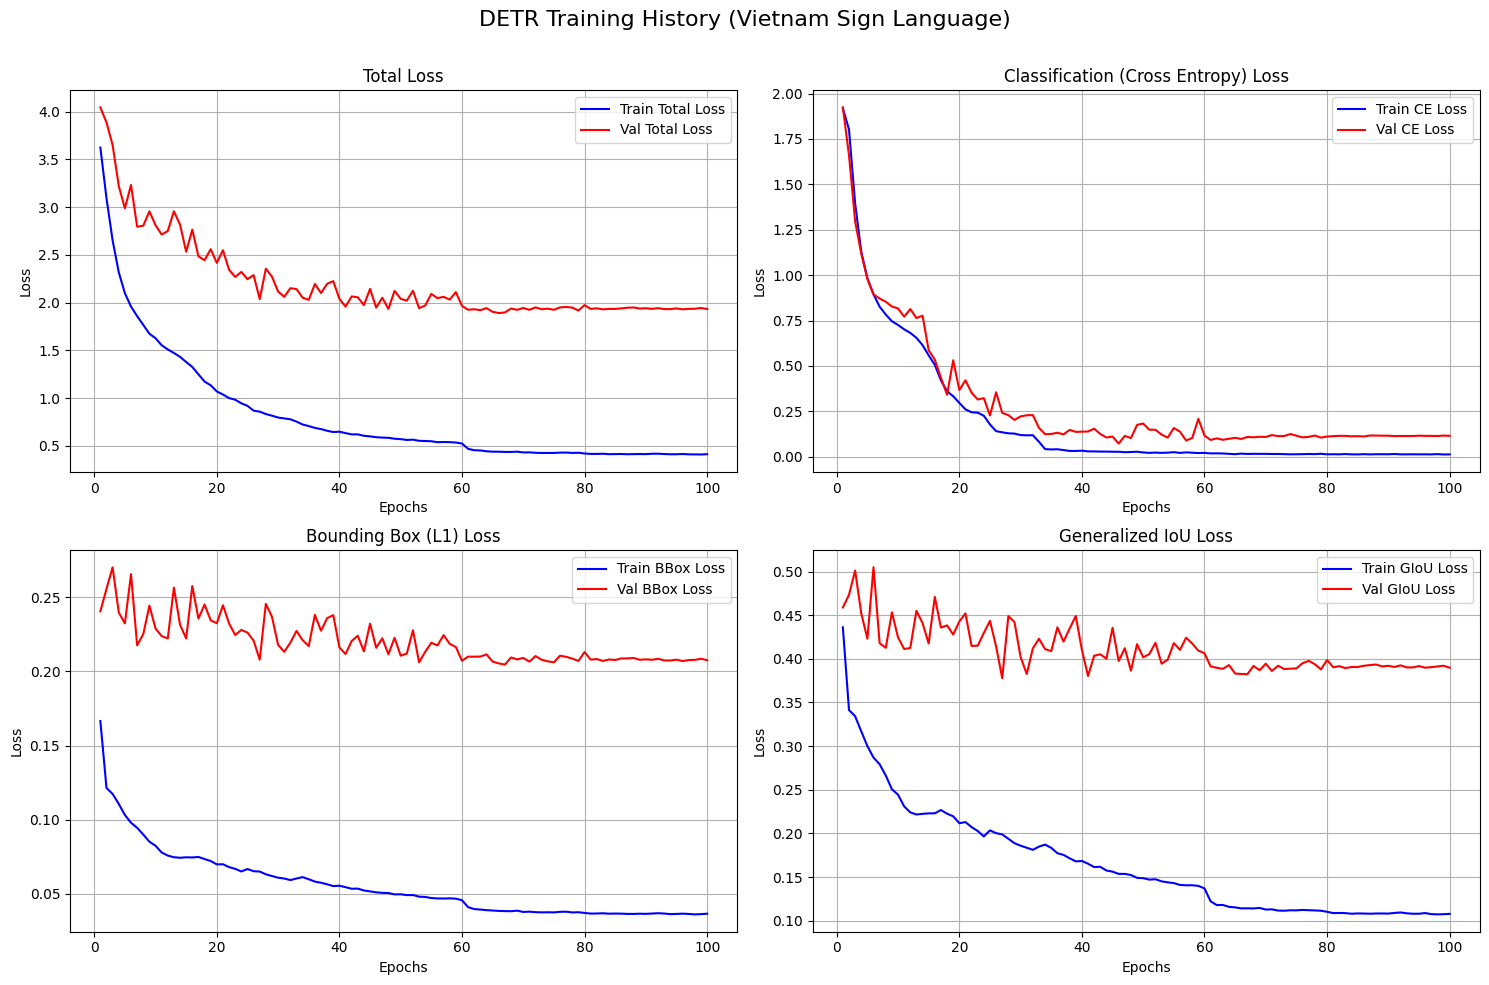

In [26]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('DETR Training History (Vietnam Sign Language)', fontsize=16)

    # 1. Total Loss
    axs[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Total Loss')
    axs[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Total Loss')
    axs[0, 0].set_title('Total Loss')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # 2. Classification Loss
    axs[0, 1].plot(epochs, history['train_ce'], 'b-', label='Train CE Loss')
    axs[0, 1].plot(epochs, history['val_ce'], 'r-', label='Val CE Loss')
    axs[0, 1].set_title('Classification (Cross Entropy) Loss')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # 3. Bounding Box L1 Loss
    axs[1, 0].plot(epochs, history['train_bbox'], 'b-', label='Train BBox Loss')
    axs[1, 0].plot(epochs, history['val_bbox'], 'r-', label='Val BBox Loss')
    axs[1, 0].set_title('Bounding Box (L1) Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # 4. GIoU Loss
    axs[1, 1].plot(epochs, history['train_giou'], 'b-', label='Train GIoU Loss')
    axs[1, 1].plot(epochs, history['val_giou'], 'r-', label='Val GIoU Loss')
    axs[1, 1].set_title('Generalized IoU Loss')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Loss')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Gọi hàm để vẽ biểu đồ
plot_training_history(history)

In [27]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def calculate_accuracy_and_deviation(model, dataloader, matcher, device):
    model.eval()

    total_matched_objects = 0
    correct_class_predictions = 0
    total_box_deviation = 0.0

    # Biến để lưu sai số riêng cho từng thành phần (Tùy chọn xem chi tiết)
    dev_cx, dev_cy, dev_w, dev_h = 0.0, 0.0, 0.0, 0.0

    pbar = tqdm(dataloader, desc="Calculating Accuracy & Deviation")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # 1. Chạy model để lấy dự đoán
        outputs = model(images)

        # 2. Dùng HungarianMatcher để tìm ra các dự đoán khớp với Ground Truth nhất
        indices = matcher(outputs, targets)

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            # Lấy ra các dự đoán và đáp án đã được ghép cặp (matched)
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- TÍNH ACCURACY (Phân loại chữ cái) ---
            # Lấy class có xác suất cao nhất (bỏ qua class nền ở index cuối)
            pred_labels = pred_logits_matched.argmax(dim=-1)
            correct_class_predictions += (pred_labels == tgt_labels_matched).sum().item()

            # --- TÍNH ĐỘ LỆCH (Box Deviation - L1 Error) ---
            # Tính sai số tuyệt đối trung bình cho 4 tọa độ (cx, cy, w, h)
            # Tọa độ đang ở dạng chuẩn hóa (0 -> 1)
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # Tính sai số chi tiết cho tâm (cx, cy) và kích thước (w, h)
            abs_diff = torch.abs(pred_boxes_matched - tgt_boxes_matched)
            dev_cx += abs_diff[:, 0].sum().item()
            dev_cy += abs_diff[:, 1].sum().item()
            dev_w  += abs_diff[:, 2].sum().item()
            dev_h  += abs_diff[:, 3].sum().item()

    # Tổng hợp kết quả
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return

    accuracy = (correct_class_predictions / total_matched_objects) * 100

    # Chia cho (số object * 4 tọa độ) để ra độ lệch trung bình trên mỗi trục tọa độ
    avg_deviation = total_box_deviation / (total_matched_objects * 4)

    avg_dev_cx = dev_cx / total_matched_objects
    avg_dev_cy = dev_cy / total_matched_objects
    avg_dev_w  = dev_w / total_matched_objects
    avg_dev_h  = dev_h / total_matched_objects

    print("\n" + "="*50)
    print(" KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST ".center(50))
    print("="*50)
    print(f"Tổng số đối tượng được test : {total_matched_objects}")
    print(f"Độ chính xác nhãn (Accuracy): {accuracy:.2f}% ({correct_class_predictions}/{total_matched_objects} đúng)")
    print("-" * 50)
    print(f"Độ lệch tổng thể (Trung bình): {avg_deviation:.4f} (theo tỷ lệ ảnh 0-1)")
    print("Chi tiết độ lệch từng thông số:")
    print(f"  - Lệch tọa độ X (cx)       : {avg_dev_cx:.4f} (~{avg_dev_cx*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch tọa độ Y (cy)       : {avg_dev_cy:.4f} (~{avg_dev_cy*100:.2f}% chiều cao ảnh)")
    print(f"  - Lệch chiều rộng (w)      : {avg_dev_w:.4f}  (~{avg_dev_w*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch chiều cao (h)       : {avg_dev_h:.4f}  (~{avg_dev_h*100:.2f}% chiều cao ảnh)")
    print("="*50)

# Gọi hàm để tính toán
calculate_accuracy_and_deviation(model, test_dataloader, matcher, device)

Calculating Accuracy & Deviation: 100%|██████████| 30/30 [00:03<00:00,  9.03it/s]


     KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST     
Tổng số đối tượng được test : 215
Độ chính xác nhãn (Accuracy): 96.74% (208/215 đúng)
--------------------------------------------------
Độ lệch tổng thể (Trung bình): 0.0481 (theo tỷ lệ ảnh 0-1)
Chi tiết độ lệch từng thông số:
  - Lệch tọa độ X (cx)       : 0.0080 (~0.80% chiều rộng ảnh)
  - Lệch tọa độ Y (cy)       : 0.0205 (~2.05% chiều cao ảnh)
  - Lệch chiều rộng (w)      : 0.0332  (~3.32% chiều rộng ảnh)
  - Lệch chiều cao (h)       : 0.1308  (~13.08% chiều cao ảnh)
